# Claris: Histopathology Cancer Detector

This project was realized for Expo-Science hosted by Hydro-Quebec.

## Introduction

Many healthcare professionals are under great pressure with the current situation of Quebec's healthcare industry. A severe lack of personnel is a prominent issue, and the efficiency in cancer diagnosis process was worsened by this problem. It is not always easy to detect cancer in images. This project aims to develop a deep learning model that can detect histopathologic cancer in images, in order to ease the process of detection and pressure on the healthcare industry.

---

## Dataset

https://www.kaggle.com/competitions/histopathologic-cancer-detection/data 

This dataset of histopathologic scans of lymph node sections is a modified version of the PCAM (PatchCamelyon) dataset.

> 
    The PatchCamelyon benchmark (PCAM) consists of 327.680 color images (96 x 96px) extracted from histopathologic scans of lymph node sections. Each image is annoted with a binary label indicating presence of metastatic tissue.
    Fundamental machine learning advancements are predominantly evaluated on straight-forward natural-image classification datasets and medical imaging is becoming one of the major applications of ML and thus deserves a spot on the list of go-to ML datasets. Both to challenge future work, and to steer developments into directions that are beneficial for this domain.


## Model

The model used in this project is Resnet-50, a type of Convolutional Neural Network (CNN) for precision purposes. The CNN is trained on the dataset using the categorical cross-entropy loss function. The model will be able to classify the images into one of the following categories: benign or malignant.

## Implementation

The implementation of the model is done with Jupyter Notebook using the Pytorch library. The model is trained on Kaggle duo-T4 GPU using the Adam optimizer. 
  
## Accuracy
The model achieved a peak accuracy of around 97.5% after 6 epochs.

![alt text](image.png)

## Sources
Thanks to many Kaggle competitions, datasets and notebooks for inspiration.

### 1) Imports and configuration

In [1]:
# Import useful libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
#import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models

from PIL import Image
from sklearn.model_selection import train_test_split


#### Setting up the environment
Using Kaggle's Nvidia GPU 

In [2]:
# Device -> Nvidia GPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Use GPU cuda if available
print('Using device:', DEVICE)

# Config
IMG_SIZE = 96
BATCH_SIZE = 64
NUM_WORKERS = 2


Using device: cuda


### 2) Data transformations
Diversify the training data by augmenting the images with random rotations, flips, and translations.

In [3]:
# Train data transformations
#  - Augmented to increase diversity of the dataset
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),            # Ensure consistent size
    transforms.RandomHorizontalFlip(),                  # Random flips (augmentation)
    transforms.RandomVerticalFlip(),                    # Random flips  (augmentation)
    transforms.RandomRotation(20),                      # Random rotations (augmentation)
    transforms.ToTensor(),                              # Convert to tensor
    transforms.Normalize(                               # Standardize pixel values
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]    # ImageNet std
    )
])

# Test data transformations (no augmentation or randomness)
val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### 3) Data loading helper class


In [4]:
class Dataset(Dataset):
    """
    Dataset for Kaggle Histopathologic Cancer Detection (based on PCAM)
    Uses .tif images + train_labels.csv
    """

    def __init__(self, img_dir, csv_path, transform=None):
        self.img_dir = img_dir
        self.transform = transform
    
        self.df = pd.read_csv(csv_path) # train_labels.csv

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx, 0]          # image id
        label  = int(self.df.iloc[idx, 1])     # 0 or 1 (cancer or not)

        img_path = os.path.join(self.img_dir, img_id + ".tif")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


### 4) Load PCam dataset


In [5]:
# Kaggle directory (PCam)
BASE_DIR = "/kaggle/input/competitions/histopathologic-cancer-detection/"

TRAIN_DIR = BASE_DIR + "train"
CSV_PATH = BASE_DIR + "train_labels.csv"

# Train / validation test split
df = pd.read_csv(CSV_PATH)

# Split into train and validation datasets
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)


#### Data loaders


In [6]:

BATCH_SIZE = 128

train_dataset = Dataset(
    TRAIN_DIR, "train_split.csv", train_tfms
)

val_dataset = Dataset(
    TRAIN_DIR, "val_split.csv", val_tfms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True, # faster GPU data transfer
    persistent_workers=True, # keep warm state for >1 epoch
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    persistent_workers=True,
    num_workers=4
)

### 5) Loading ResNet-50 model
The model has been pre-trained on ImageNet. <br>
Hence, the model already knows how to detect edges, textures, patterns, colors, etc.


In [ ]:
# Load pretrained Resnet50 from torchvision
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Replace the classifier layer (fully connected layer)
# ResNet outputs 2048 features → we need 2 classes for benign / malignant
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

# Wrap for multi-GPU
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = torch.nn.DataParallel(model) # parallel computing
    
model = model.to(DEVICE)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 175MB/s] 


Using 2 GPUs!


#### Loss function and optimizer

In [8]:
# Class imbalance handling
class_weights = torch.tensor([1.0, 1.5]).to(DEVICE)

# Binary classification
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Prevent underflow (~0 gradient rounded to 0)
scaler = torch.amp.GradScaler() 

### 6) Training the model!

In [9]:
def train_one_epoch(model, loader):
    model.train()  # training mode
    running_loss = 0.0
    
    loop = tqdm(train_loader, total=len(train_loader))

    for images, labels in loader:
        # Move data to device (GPU)
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        # Reset gradients
        optimizer.zero_grad()
        
        # Mixed precision training for faster training
        # COMPARE RESULTS AND PENALIZE LOSS
        with torch.amp.autocast("cuda"):
            # Forward pass (prediction results)
            outputs = model(images)
            # Compute loss
            loss = criterion(outputs, labels)

        # Backpropagation (how should each weight change to make the loss smaller?)
        scaler.scale(loss).backward() # loss.backward()

        # Update weights for real
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        
        loop.set_postfix(loss=running_loss / (loop.n+1))

    return running_loss / len(loader)


#### Validation

In [10]:
def validate(model, loader):
    model.eval()  # evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating", leave=False): # Progress bar
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total


### 7) Visualizing prediction results


In [11]:
# Plotting for visualization

def plot_validation_accuracy(val_history):
    epochs = range(1, len(val_history) + 1)
    
    plt.figure(figsize=(10, 6))
    # Plot only the validation data
    plt.plot(epochs, val_history, marker='s', linestyle='-', color='r', label='Validation Accuracy')
    
    plt.title("Evolution of ResNet-50 Model Validation Accuracy")
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    plt.show()

  0%|          | 0/1376 [08:37<?, ?it/s, loss=312]  


Epoch [1/60] Train Loss: 0.2267 | Val Acc: 95.14%


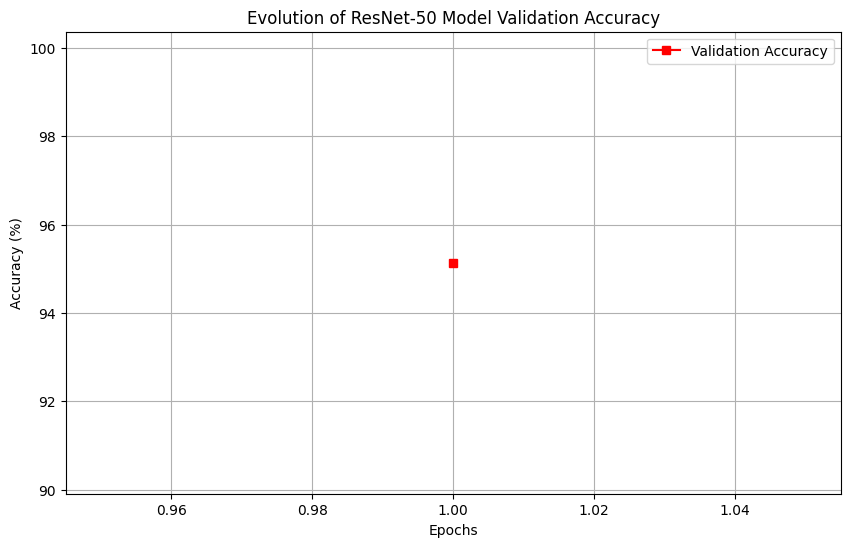

  0%|          | 0/1376 [07:05<?, ?it/s, loss=192]  


Epoch [2/60] Train Loss: 0.1395 | Val Acc: 96.39%


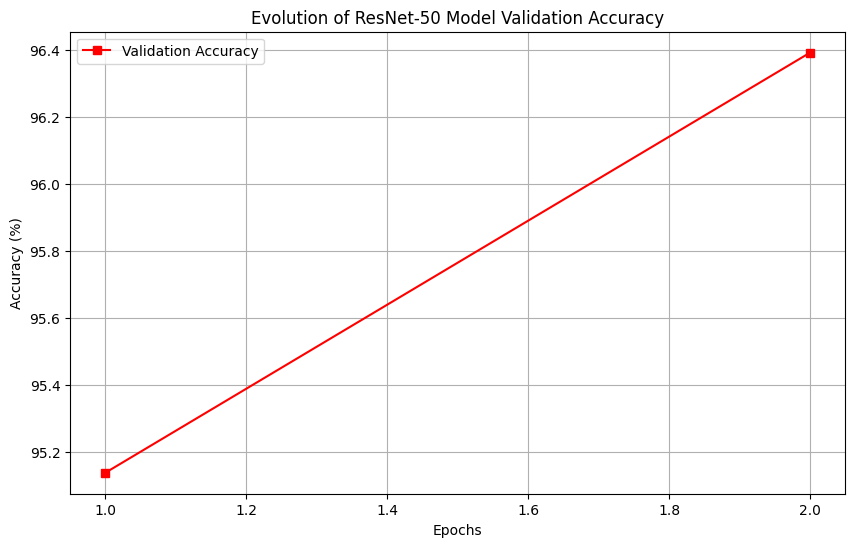

  0%|          | 0/1376 [07:02<?, ?it/s, loss=159]  


Epoch [3/60] Train Loss: 0.1156 | Val Acc: 96.59%


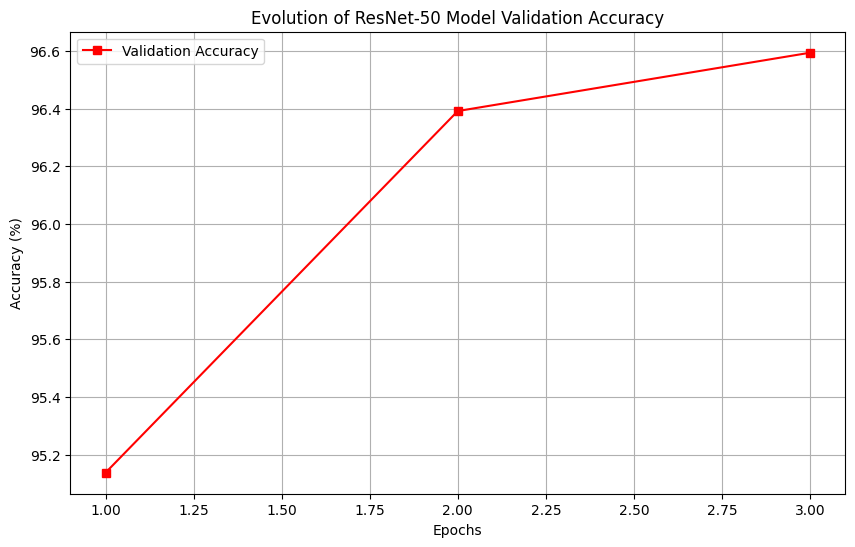

  0%|          | 0/1376 [06:56<?, ?it/s, loss=136]  


Epoch [4/60] Train Loss: 0.0990 | Val Acc: 96.83%


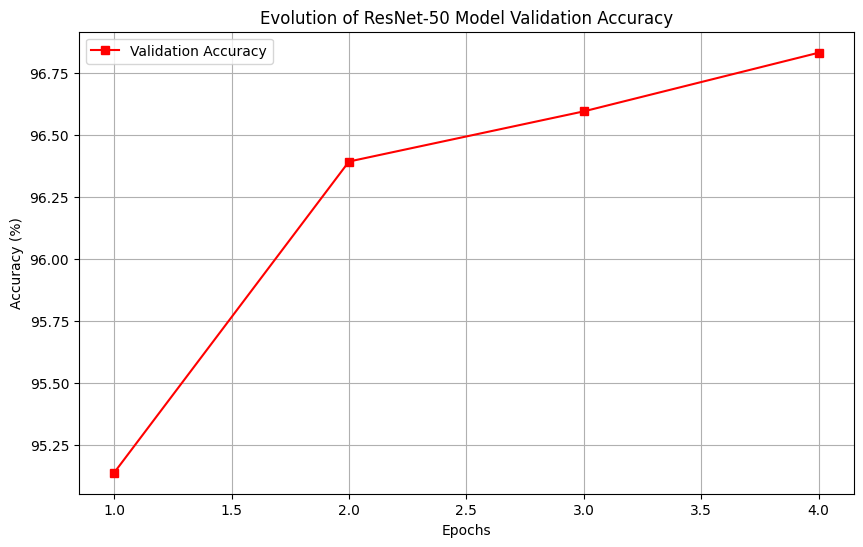

  0%|          | 0/1376 [06:51<?, ?it/s, loss=122]   


Epoch [5/60] Train Loss: 0.0889 | Val Acc: 97.22%


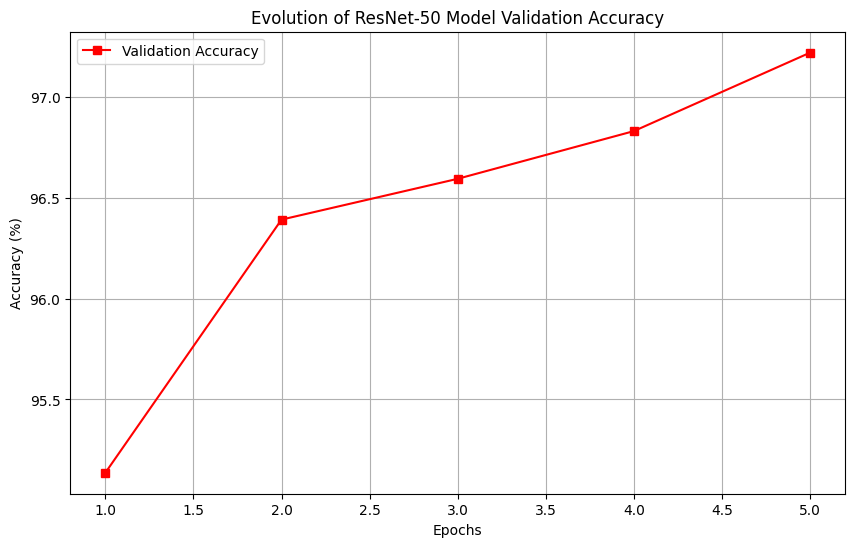

  0%|          | 0/1376 [06:52<?, ?it/s, loss=111]   


Epoch [6/60] Train Loss: 0.0804 | Val Acc: 97.13%


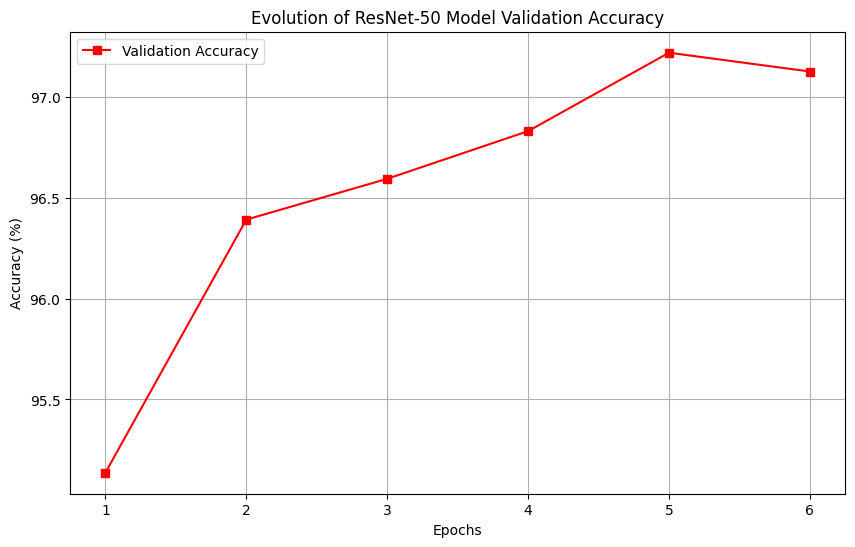

  0%|          | 0/1376 [07:00<?, ?it/s, loss=101]   


Epoch [7/60] Train Loss: 0.0737 | Val Acc: 97.73%


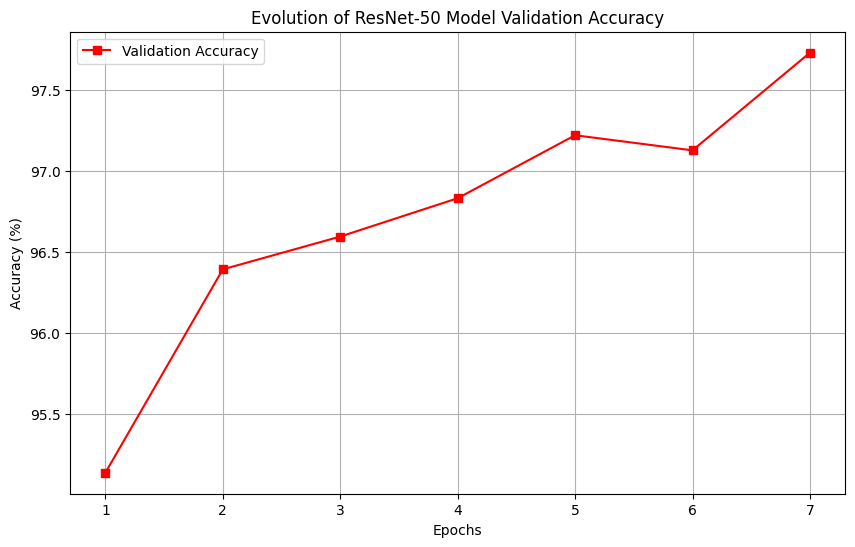

  0%|          | 0/1376 [06:57<?, ?it/s, loss=91.7]  


Epoch [8/60] Train Loss: 0.0666 | Val Acc: 97.75%


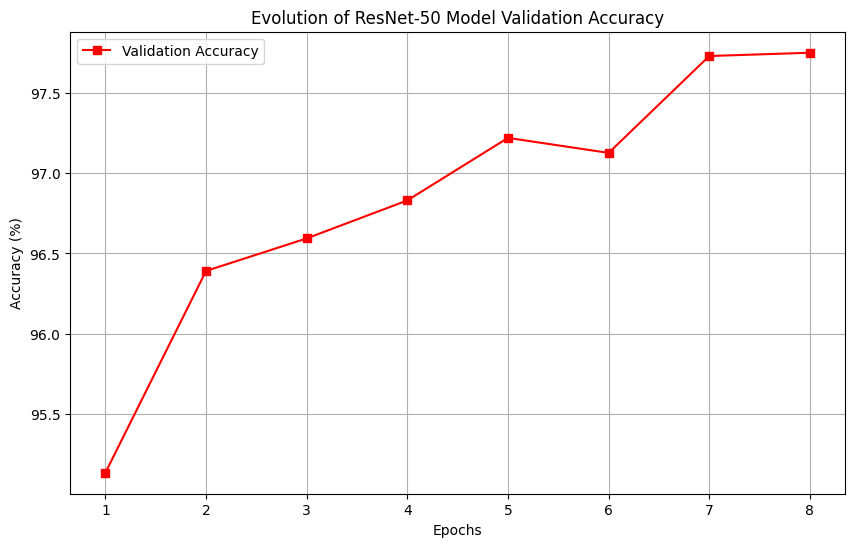

  0%|          | 0/1376 [06:33<?, ?it/s, loss=85.7]  


Epoch [9/60] Train Loss: 0.0623 | Val Acc: 97.80%


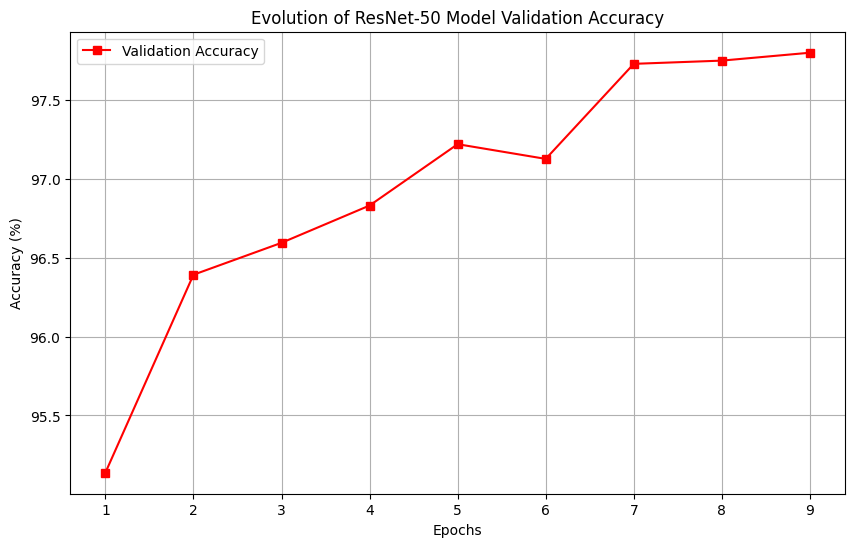

  0%|          | 0/1376 [06:55<?, ?it/s, loss=79.1] 


Epoch [10/60] Train Loss: 0.0575 | Val Acc: 97.41%


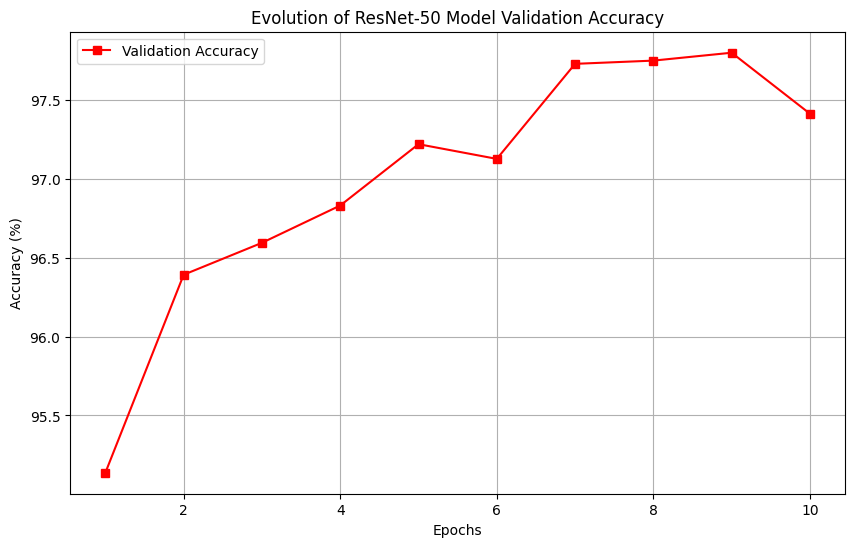

  0%|          | 0/1376 [06:59<?, ?it/s, loss=73.2]  


Epoch [11/60] Train Loss: 0.0532 | Val Acc: 97.90%


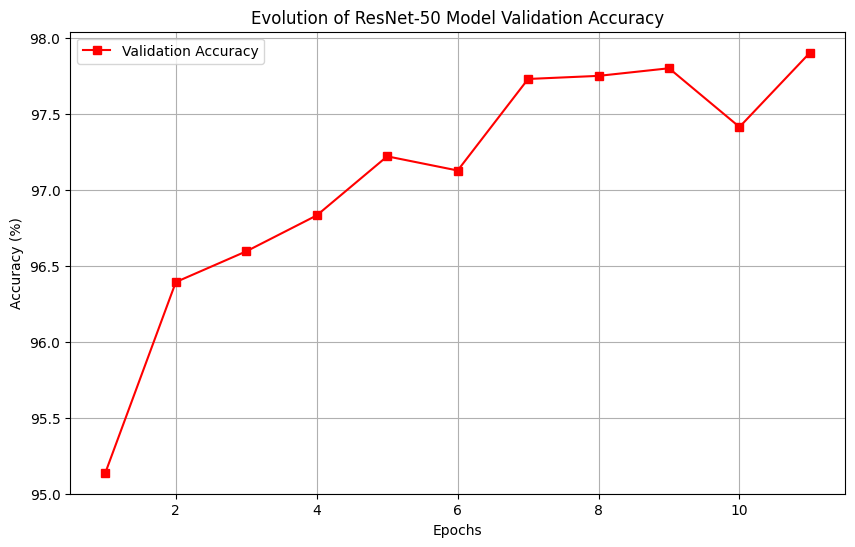

  0%|          | 0/1376 [06:51<?, ?it/s, loss=68.5]  
                                                             

Epoch [12/60] Train Loss: 0.0498 | Val Acc: 97.44%


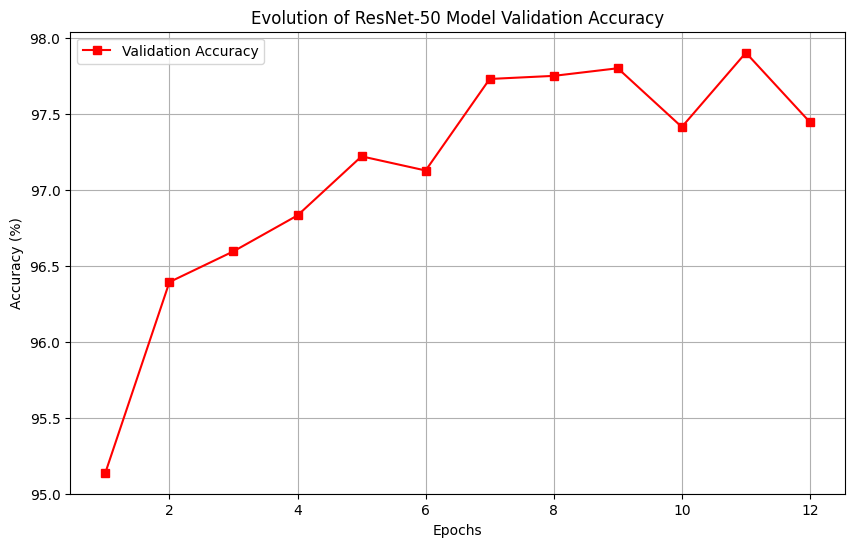

  0%|          | 0/1376 [06:51<?, ?it/s, loss=65]    


Epoch [13/60] Train Loss: 0.0472 | Val Acc: 97.96%


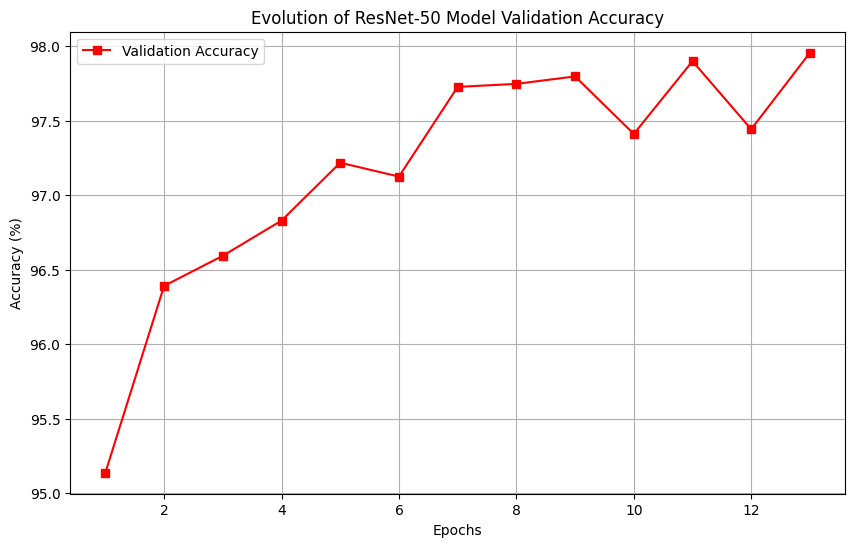

  0%|          | 0/1376 [06:53<?, ?it/s, loss=60.4] 


Epoch [14/60] Train Loss: 0.0439 | Val Acc: 97.97%


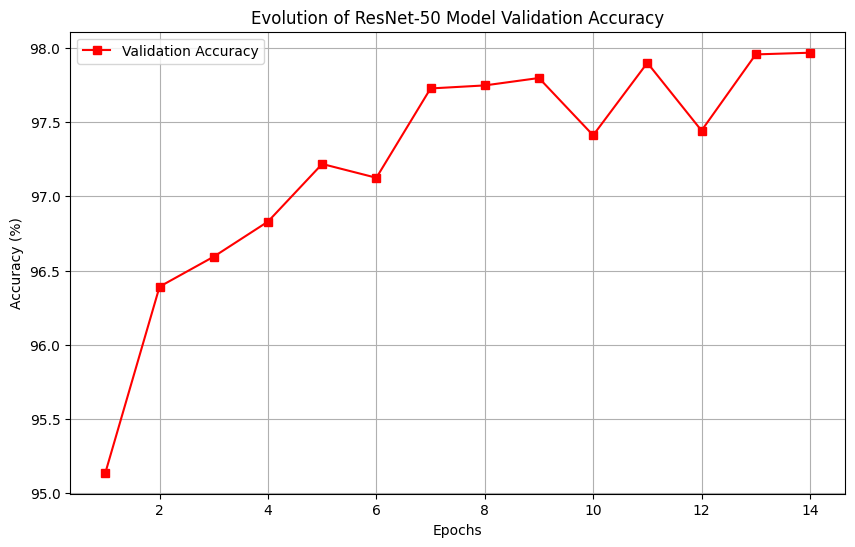

  0%|          | 0/1376 [06:49<?, ?it/s, loss=57.1]  


Epoch [15/60] Train Loss: 0.0415 | Val Acc: 98.10%


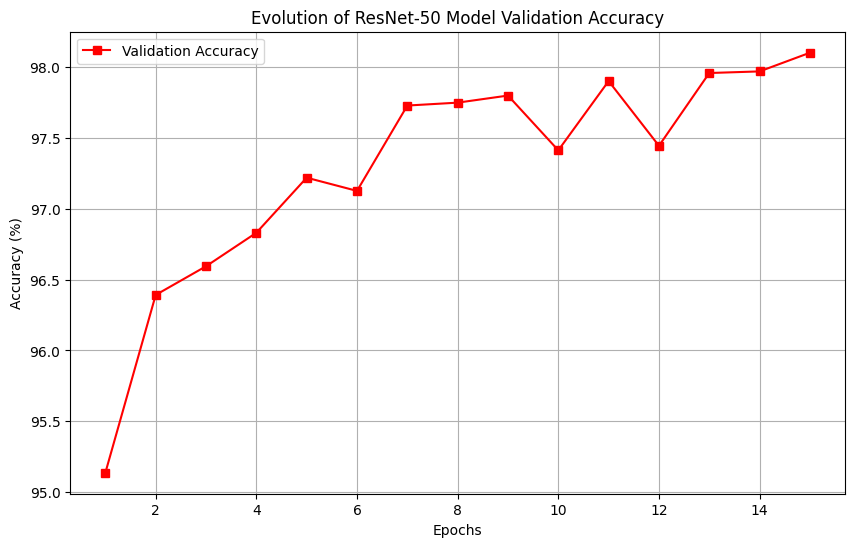

  0%|          | 0/1376 [06:59<?, ?it/s, loss=53.8]  


Epoch [16/60] Train Loss: 0.0391 | Val Acc: 97.95%


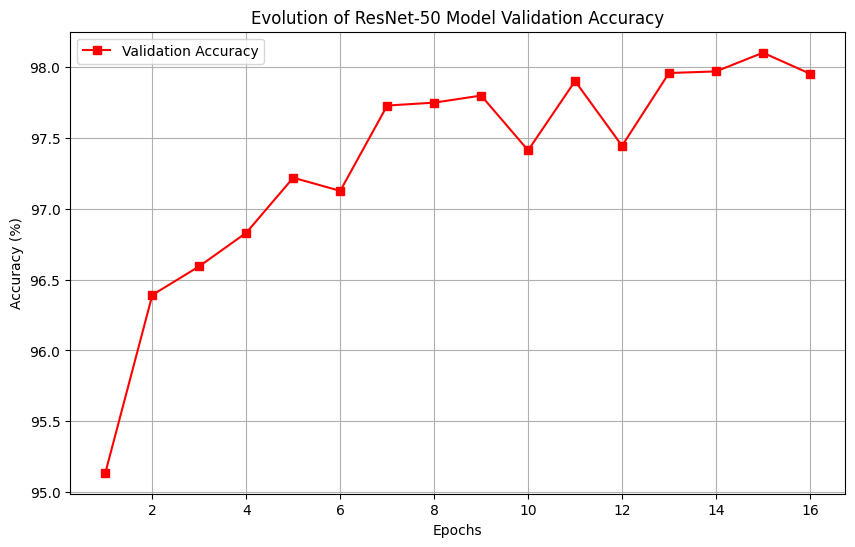

  0%|          | 0/1376 [00:37<?, ?it/s, loss=5.22]  

KeyboardInterrupt: 

In [12]:
EPOCHS = 20  # increase later

val_acc_history = []

for epoch in range(EPOCHS):
      
    train_loss = train_one_epoch(model, train_loader)
    val_acc = validate(model, val_loader)
    
    # Save history for accuracy graph
    val_acc_history.append(val_acc * 100)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Acc: {val_acc*100:.2f}%")
    
    plot_validation_accuracy(val_acc_history)
    
    # Save model
    torch.save(model.state_dict(), "pcam_model-resnet.pth")
